# CKD 예측 모델 성능 평가 (평가 3-1)

학습 미사용 **test set**(`test_final_v2.csv`)으로 모델1(임상 42피처)·모델2(생활습관 24피처)를 평가한다. 양성률 약 4%의 불균형 문제이므로 ROC-AUC와 함께 **PR-AUC·Brier**를 핵심 지표로 본다.

> 재현: `CKD_DATA_DIR=<*_final_v2.csv 디렉토리>` 환경에서 `ckd-venv-train`(Python 3.11 + AutoGluon) 커널로 실행.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve, roc_auc_score, roc_curve

from src.ckd import config

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 9

/Users/junhee_johnny/workspaces/oz_coding/20project/AI_HealthCare_Final_Project/.venv-train/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 데이터 분할

train/val/test 3분할 중 **test만** 평가에 사용(학습·임계값 산출 미사용 → 누수 없음).

In [2]:
test = pd.read_csv(config.TEST_CSV)
y = test[config.LABEL].to_numpy().astype(int)
print(f"test shape: {test.shape}")
print(f"CKD 양성: {y.sum()} / {len(y)}  (양성률 {y.mean():.4f})")

test shape: (8964, 52)
CKD 양성: 357 / 8964  (양성률 0.0398)


## 2. 모델별 test 예측 + 핵심 지표

AutoGluon predictor를 로드해 양성 확률을 예측한다.

In [3]:
def predict(model_dir, features):
    p = TabularPredictor.load(str(model_dir))
    return p.predict_proba(test[features])[1].to_numpy()


proba1 = predict(config.MODEL1_DIR, config.MODEL1_FEATURES)
proba2 = predict(config.MODEL2_DIR, config.MODEL2_FEATURES)


def metrics(p):
    return {"ROC-AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p), "Brier": brier_score_loss(y, p)}


pd.DataFrame({"모델1 (임상 42)": metrics(proba1), "모델2 (생활습관 24)": metrics(proba2)}).round(4)

,모델1 (임상 42),모델2 (생활습관 24)
ROC-AUC,0.9023,0.8828
PR-AUC,0.3513,0.2951
Brier,0.0309,0.0326


## 3. ROC 곡선

두 모델 모두 목표 AUROC 0.80을 초과한다.

/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/3274838076.py:6: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.title('ROC Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/3274838076.py:6: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.title('ROC Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/3274838076.py:6: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.title('ROC Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/3274838076.py:6: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  plt.title('ROC Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/

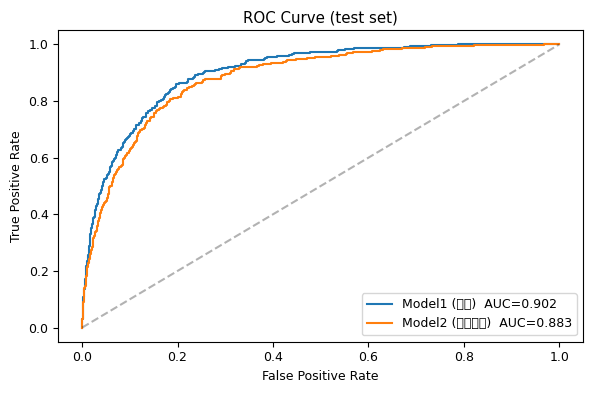

In [4]:
for name, p in [("Model1 (임상)", proba1), ("Model2 (생활습관)", proba2)]:
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, label=f"{name}  AUC={roc_auc_score(y, p):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Precision-Recall 곡선

불균형(양성 4%)에서 소수 양성 탐지력을 본다. 점선은 무작위 기준선(=양성률).

/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/83719569.py:6: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.title('Precision-Recall Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/83719569.py:6: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.title('Precision-Recall Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/83719569.py:6: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.title('Precision-Recall Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/83719569.py:6: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  plt.title('Precision-Recall Curve (test set)'); pl

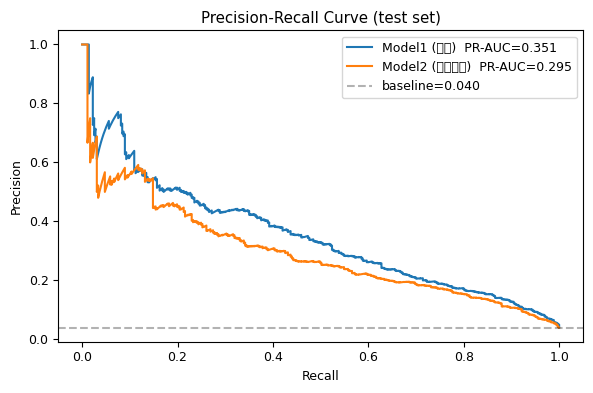

In [5]:
for name, p in [("Model1 (임상)", proba1), ("Model2 (생활습관)", proba2)]:
    prec, rec, _ = precision_recall_curve(y, p)
    plt.plot(rec, prec, label=f"{name}  PR-AUC={average_precision_score(y, p):.3f}")
plt.axhline(y.mean(), ls="--", c="k", alpha=0.3, label=f"baseline={y.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. 신뢰도 보정 (Calibration)

예측 확률이 실제 빈도와 얼마나 일치하는지(대각선=완벽 보정).

/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/1939004027.py:6: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.title('Calibration Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/1939004027.py:6: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.title('Calibration Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/1939004027.py:6: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.title('Calibration Curve (test set)'); plt.legend(); plt.tight_layout(); plt.show()
/var/folders/gf/b0xxd8rs3130cbhm9pr6d8d80000gn/T/ipykernel_97664/1939004027.py:6: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.title('Calibration Curve (test set)'); plt.legend();

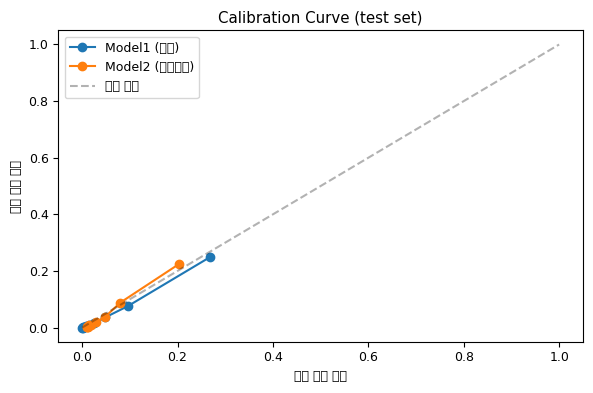

In [6]:
for name, p in [("Model1 (임상)", proba1), ("Model2 (생활습관)", proba2)]:
    frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac, "o-", label=name)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="완벽 보정")
plt.xlabel("평균 예측 확률")
plt.ylabel("실제 양성 빈도")
plt.title("Calibration Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. 결론

- **모델1 ROC-AUC 0.902 / 모델2 0.883** — 두 모델 모두 목표(0.80) 초과, 모델1이 임상 마커 덕에 우위
- 불균형에서 PR-AUC가 baseline(0.04) 대비 8~9배, Brier 0.03으로 보정 양호
- 임계값별 분류 지표·선별 정책 해석은 `docs/model-eval/README.md` 참조
- 추론은 산출물 동결로 **완전 결정론**(편차 0, `scripts/check_determinism.py`)